<table align="left" width=100%>
    <tr>
        <td width="20%">
            <img src="faculty.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                  <b> Faculty Notebook <br> (Session 3) </b>
                </font>
            </div>
        </td>
    </tr>
</table>

## Problem Statement

The New York City Controller's Office maintains a database of the salary and benefits paid to city employees since the fiscal year 2013. This is data representing the Employee Compensation report.

**Year Type:**		Fiscal (July through June) or Calendar (January through December)<br>

**Year:**		An accounting period of 12 months. The New York City operates operates on a fiscal year that begins on July 1 and ends on June 30 the following year. The Fiscal Year ending June 30, 2012 is represented as FY2011-2012.<br>

**Employee Identifier:**		Each distinct number in the “Employee Identifier” column represents one employee. These identifying numbers are not meaningful but rather are randomly assigned for the purpose of building this dataset.<br> 

**Salaries:**		Normal salaries paid to permanent or temporary City employees. <br>

**Overtime:**		Amounts paid to City employees working in excess of 40 hours per week. <br>

**Other Salaries:**		Various irregular payments made to City employees including premium pay, incentive pay, or other one-time payments. <br>

**Total Salary:**		The sum of all salaries paid to City employees.<br>

**Retirement:**		City contributions to employee retirement plans. <br>

**Health/Dental:**		City-paid premiums to health and dental insurance plans covering City employees. To protect confidentiality as legally required, pro-rated citywide averages are presented in lieu of employee-specific health and dental benefits. <br>

**Other Benefits:**		Mandatory benefits paid on behalf of employees, such as Social Security (FICA and Medicare) contributions, unemployment insurance premiums, and minor discretionary benefits not included in the above categories.<br>

**Total Benefits:**		The sum of all benefits paid to City employees.<br>

**Total Compensation:**		The sum of all salaries and benefits paid to City employees.

<a id="lib"></a>
# 1. Import Libraries

In [13]:
# import 'Pandas' 
import pandas as pd 

# import 'Numpy' 
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn' 
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None
 
# to display the float values upto 6 decimal places     
pd.options.display.float_format = '{:.6f}'.format

# import train-test split 
from sklearn.model_selection import train_test_split

# import various functions from statsmodel to perform linear regression
import statsmodels
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
from statsmodels.tools.eval_measures import rmse

# import various functions from scipy
from scipy import stats
from scipy.stats import shapiro

# 'metrics' from sklearn is used for evaluating the model performance
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

<a id="prep"></a>
# 2. Data Preparation

<a id="read"></a>
## 2.1 Understand the Data

In [14]:
# load the csv file
# store the data in 'df_compensation'
df_compensation = pd.read_csv('employee_compensation.csv')

# display first five observations using head()
df_compensation.head()

,Year_Type,Year,Employee_Identifier,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,42853,92288.220000,267.450000,267.450000,92823.120000,20700.200000,12500.560000,7605.750000,40806.510000,133629.630000
1,Calendar,2015,28248,1466.380000,348.230000,0.000000,1814.610000,0.000000,442.030000,141.590000,583.620000,2398.230000
2,Fiscal,2014,30651,76536.950000,13583.720000,10855.940000,100976.610000,18632.190000,12464.610000,8011.410000,39108.210000,140084.820000
3,Fiscal,2014,19473,45659.880000,0.000000,1625.370000,47285.250000,10081.200000,0.000000,3936.630000,14017.830000,61303.080000
4,Fiscal,2013,7176,41832.000000,0.000000,0.000000,41832.000000,7617.600000,5908.520000,3254.500000,16780.620000,58612.620000


In [15]:
# use 'shape' to check the dimension of data
df_compensation.shape

(50000, 12)

In [16]:
# use 'info()' to understand the dataset
df_compensation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Type            50000 non-null  object 
 1   Year                 50000 non-null  int64  
 2   Employee_Identifier  50000 non-null  int64  
 3   Salaries             50000 non-null  float64
 4   Overtime             50000 non-null  float64
 5   Other_Salaries       50000 non-null  float64
 6   Total_Salary         50000 non-null  float64
 7   Retirement           50000 non-null  float64
 8   Health/Dental        50000 non-null  float64
 9   Other_Benefits       50000 non-null  float64
 10  Total_Benefits       50000 non-null  float64
 11  Total_Compensation   50000 non-null  float64
dtypes: float64(9), int64(2), object(1)
memory usage: 4.6+ MB


In [17]:
# convert numerical variables to categorical (object) 
# use astype() to change the data type

# change the data type of 'Year'
df_compensation['Year'] = df_compensation['Year'].astype(object)

#### Recheck the data type after the conversion. 

In [18]:
# recheck the data types using 'dtypes'
df_compensation.dtypes

Year_Type               object
Year                    object
Employee_Identifier      int64
Salaries               float64
Overtime               float64
Other_Salaries         float64
Total_Salary           float64
Retirement             float64
Health/Dental          float64
Other_Benefits         float64
Total_Benefits         float64
Total_Compensation     float64
dtype: object

<a id="drop"></a>
## 2.3 Remove Insignificant Variables

In [19]:
# drop the column 'Employee_Identifier' using drop()
# 'axis = 1' drops the specified column
df_compensation = df_compensation.drop('Employee_Identifier',axis=1)

<a id="outlier"></a>
## 2.2 Outlier Analysis and Treatment

**Check the outliers in all the variables and treat them using appropriate techniques.**

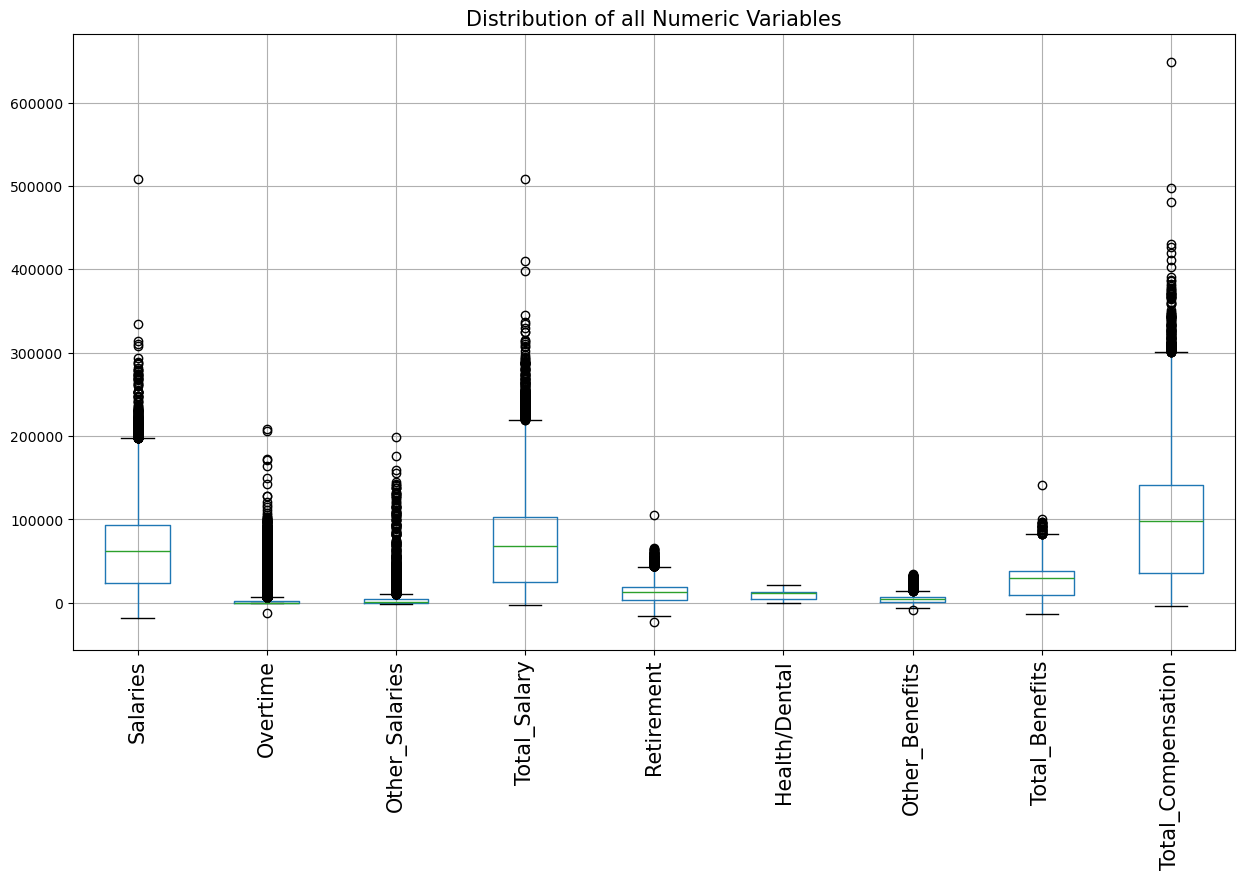

In [20]:
# set the plot size using figure()
# pass width and height in inches to 'figsize' 
plt.figure(figsize = (15,8))

# plot a boxplot to visualize the outliers in all the numeric variables
df_compensation.boxplot()

# set plot label
# set text size using 'fontsize'
plt.title('Distribution of all Numeric Variables', fontsize = 15)

# xticks() returns the x-axis ticks
# 'rotation = vertical' rotates the x-axis labels vertically
plt.xticks(rotation = 'vertical', fontsize = 15)

# display the plot
plt.show()

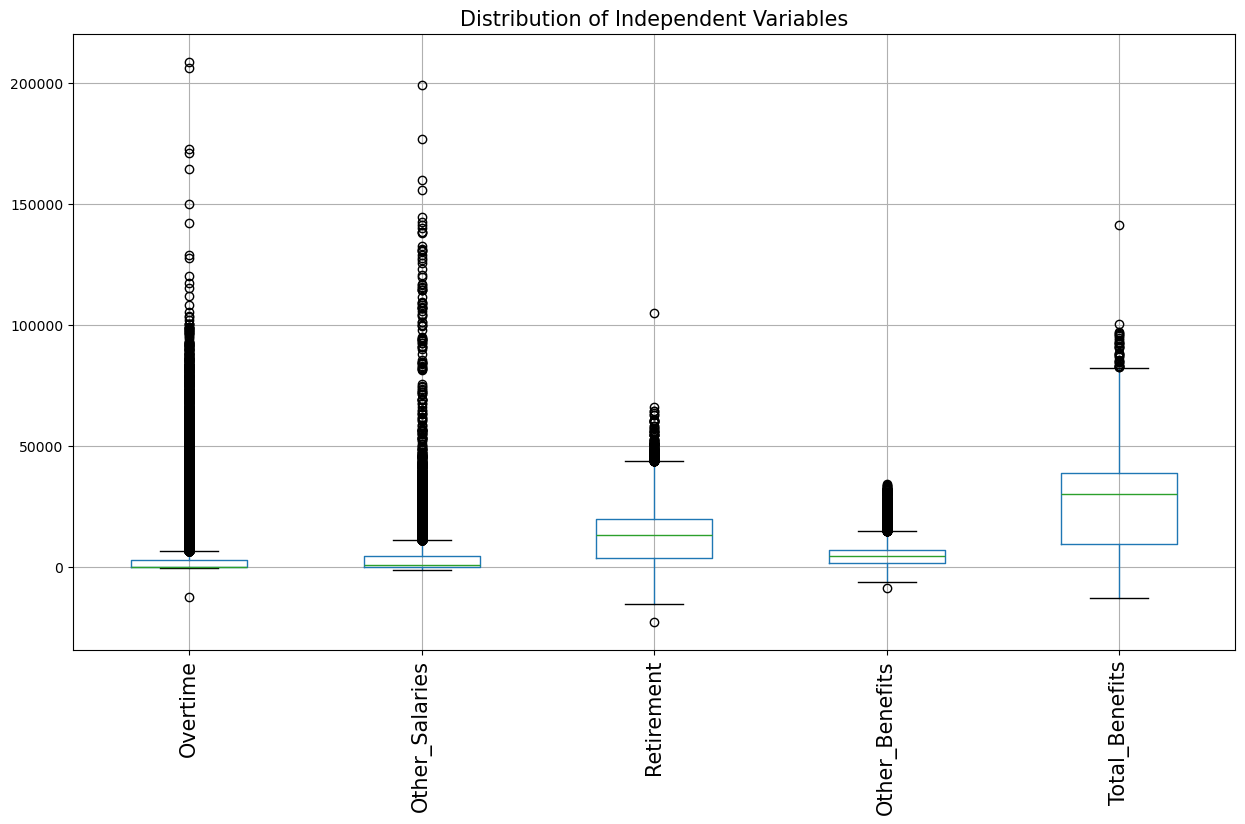

In [21]:
# boxplot of independent variables

# set the plot size using figure()
# pass width and height in inches to 'figsize' 
plt.figure(figsize = (15,8))

# plot boxplots of all the numeric variables except the variables 'Salaries', 'Total_Salary' and 'Total_Compensation' 
# use 'loc[]' to select the variables
df_compensation.loc[:,['Overtime', 'Other_Salaries', 'Retirement', 'Other_Benefits', 'Total_Benefits']].boxplot()

# set plot label
# set text size using 'fontsize'
plt.title('Distribution of Independent Variables', fontsize = 15)

# xticks() returns the x-axis ticks
# 'rotation = vertical' rotates the x-axis labels vertically
plt.xticks(rotation = 'vertical', fontsize = 15)

# display the plot
plt.show()

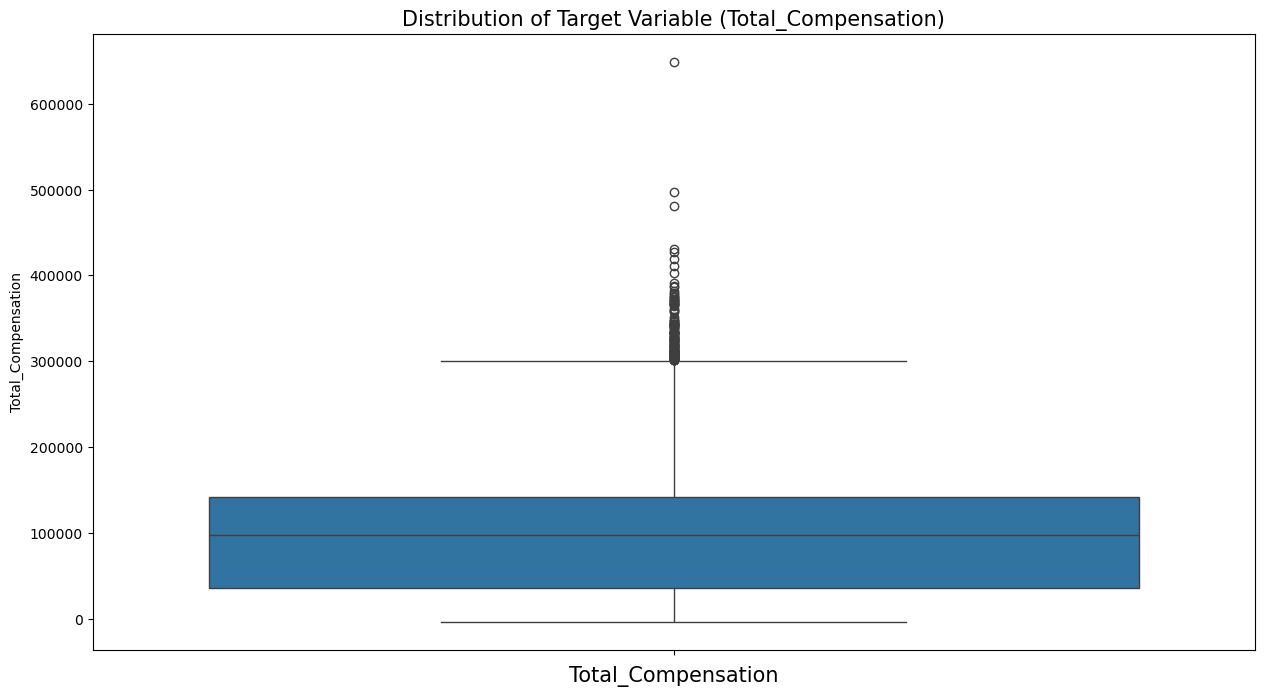

In [22]:
# set the plot size using figure()
# pass width and height in inches to 'figsize' 
plt.figure(figsize = (15,8))

# plot boxplot for 'Total_Compensation' using seaborn library
sns.boxplot(df_compensation['Total_Compensation'])

# add plot and axis labels
# set text size using 'fontsize'
plt.title('Distribution of Target Variable (Total_Compensation)', fontsize = 15)
plt.xlabel('Total_Compensation', fontsize = 15)

# display the plot
plt.show()

In [25]:
df_compensation.head()

,Year_Type,Year,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,92288.220000,267.450000,267.450000,92823.120000,20700.200000,12500.560000,7605.750000,40806.510000,133629.630000
1,Calendar,2015,1466.380000,348.230000,0.000000,1814.610000,0.000000,442.030000,141.590000,583.620000,2398.230000
2,Fiscal,2014,76536.950000,13583.720000,10855.940000,100976.610000,18632.190000,12464.610000,8011.410000,39108.210000,140084.820000
3,Fiscal,2014,45659.880000,0.000000,1625.370000,47285.250000,10081.200000,0.000000,3936.630000,14017.830000,61303.080000
4,Fiscal,2013,41832.000000,0.000000,0.000000,41832.000000,7617.600000,5908.520000,3254.500000,16780.620000,58612.620000


In [23]:
# calculate the first quartile
Q1 = df_compensation.quantile(0.25)

# calculate the third quartile
Q3 = df_compensation.quantile(0.75)

# The Interquartile Range (IQR) is defined as the difference between the third and first quartile
# calculate IQR for each numeric variable
IQR = Q3 - Q1

# retrieve the dataframe without the outliers
# '~' returns the values that do not satisfy the given conditions 
# i.e. it returns values between the range [Q1-1.5*IQR, Q3+1.5*IQR]
# '|' is used as 'OR' operator on multiple conditions   
# 'any(axis=1)' checks the entire row for atleast one 'True' entry (those rows represents outliers in the data)
df_compensation = df_compensation[~((df_compensation < (Q1 - 1.5 * IQR)) | (df_compensation > (Q3 + 1.5 * IQR))).any(axis=1)]

# check the shape of the data
df_compensation.shape

TypeError: unsupported operand type(s) for -: 'str' and 'str'

<a id="null"></a>
## 2.3 Missing Value Analysis and Treatment

**Check the presence of missing values in the data and treat them.**

In [26]:
# sort the variables on the basis of total null values in the variable
# 'isnull().sum()' returns the number of missing values in each variable
# 'ascending = False' sorts values in the descending order
# the variable with highest number of missing values will appear first
Total = df_compensation.isnull().sum().sort_values(ascending=False)          

# calculate percentage of missing values
# 'ascending = False' sorts values in the descending order
# the variable with highest percentage of missing values will appear first
Percent = (df_compensation.isnull().sum()*100/df_compensation.isnull().count()).sort_values(ascending=False)   

# concat the 'Total' and 'Percent' columns using 'concat' function
# pass a list of column names in parameter 'keys' 
# 'axis = 1' concats along the columns
missing_data = pd.concat([Total, Percent], axis=1, keys=['Total', 'Percentage of Missing Values'])    
missing_data

,Total,Percentage of Missing Values
Year_Type,0,0.000000
Year,0,0.000000
Salaries,0,0.000000
Overtime,0,0.000000
Other_Salaries,0,0.000000
Total_Salary,0,0.000000
Retirement,0,0.000000
Health/Dental,0,0.000000
Other_Benefits,0,0.000000
Total_Benefits,0,0.000000


<a id="scale"></a>
## 2.4 Scale the Data

In [27]:
df_compensation.head()

,Year_Type,Year,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,92288.220000,267.450000,267.450000,92823.120000,20700.200000,12500.560000,7605.750000,40806.510000,133629.630000
1,Calendar,2015,1466.380000,348.230000,0.000000,1814.610000,0.000000,442.030000,141.590000,583.620000,2398.230000
2,Fiscal,2014,76536.950000,13583.720000,10855.940000,100976.610000,18632.190000,12464.610000,8011.410000,39108.210000,140084.820000
3,Fiscal,2014,45659.880000,0.000000,1625.370000,47285.250000,10081.200000,0.000000,3936.630000,14017.830000,61303.080000
4,Fiscal,2013,41832.000000,0.000000,0.000000,41832.000000,7617.600000,5908.520000,3254.500000,16780.620000,58612.620000


In [28]:
# scale the independent numeric variables
df_compensation.iloc[:, 2:11] = df_compensation.iloc[:, 2:11].apply(lambda rec: (rec - rec.mean()) / rec.std())

df_compensation.head()

,Year_Type,Year,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Total_Compensation
0,Fiscal,2015,0.648705,-0.369314,-0.456892,0.411547,0.791772,0.733102,0.779346,0.850618,0.528052
1,Calendar,2015,-1.377859,-0.362024,-0.492148,-1.329386,-1.317033,-1.723007,-1.189746,-1.537720,-1.405486
2,Fiscal,2014,0.297237,0.832423,0.938918,0.567518,0.581096,0.725779,0.886362,0.749777,0.623161
3,Fiscal,2014,-0.391742,-0.393450,-0.277886,-0.459563,-0.290025,-1.813040,-0.188591,-0.740029,-0.537594
4,Fiscal,2013,-0.477156,-0.393450,-0.492148,-0.563880,-0.541001,-0.609580,-0.368541,-0.575981,-0.577234


<a id="def"></a>
# 3. What is Regression Analysis?

<a id="Bivariate"></a>
# 4. Bivariate Regression

<a id="lsm"></a>
## 4.1 Ordinary Least Square Method (OLS)

In [29]:
# split the independent and target variable into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code 
# 'test_size' returns the proportion of data to be included in the testing set
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(df_compensation['Total_Benefits'], df_compensation['Total_Compensation'], 
                                                    random_state=1, test_size = 0.3)

# check the dimensions of the train & test subset using 'shape'
# print dimension of train set
print('X_train_slr', X_train_slr.shape)
print('y_train_slr', y_train_slr.shape)

# print dimension of test set
print('X_test_slr', X_test_slr.shape)
print('y_test_slr', y_test_slr.shape)

X_train_slr (35000,)
y_train_slr (35000,)
X_test_slr (15000,)
y_test_slr (15000,)


In [30]:
# convert the X_train to DataFrame
X_train_slr = pd.DataFrame(X_train_slr)

# insert a column of intercept to 'X_train_slr'
# create an array of ones with length equal to the total number of observations
c = np.ones(X_train_slr.shape[0])

# A design matrix is a matrix of observations of independent variables whose first column is of ones
# If there are 'm' observations and 'n' variables, then the dimension of a design matrix is m * (n+1) 

# add the intercept 
# pass location index of intercept to the parameter 'loc'
# pass column name to the parameter 'column'
# pass the column value to the parameter 'value'
X_train_slr.insert(loc = 0, column = 'intercept', value = c)

# display the first five rows of design matrix
X_train_slr.head()

,intercept,Total_Benefits
8950,1.000000,0.410540
38421,1.000000,-0.325523
19363,1.000000,0.788228
30157,1.000000,-1.504669
14294,1.000000,1.061427


In [31]:
# building a model on the train dataset with an intercept
# fit() is used to fit the OLS model
SLR_model = sm.OLS(y_train_slr, X_train_slr).fit()

# print the summary output
print(SLR_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                 2.818e+05
Date:                Sat, 11 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:10:43   Log-Likelihood:                -11146.
No. Observations:               35000   AIC:                         2.230e+04
Df Residuals:                   34998   BIC:                         2.231e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          0.0012      0.002      0.

In [32]:
# predict the Total_Compensation using 'predict()' on training data
y_train_slr_pred = SLR_model.predict(X_train_slr)

# display the first five predicted values 
y_train_slr_pred.head()

8950     0.388934
38421   -0.306304
19363    0.745674
30157   -1.420052
14294    1.003721
dtype: float64

<a id="mv"></a>
## 4.2 Measures of Variation

<a id="ssr"></a>
### 4.2.1  Sum of Squared Residuals (SSR)

In [33]:
# calculate the SSR on train dataset
ssr = np.sum((y_train_slr_pred - y_train_slr.mean())**2)
ssr

np.float64(31194.28604374974)

<a id="sse"></a>
### 4.2.2 Sum of Squared Error (SSE)

In [34]:
# calculate the SSE on train dataset
sse = np.sum((y_train_slr - y_train_slr_pred)**2)
sse

np.float64(3874.451759296136)

<a id="sst"></a>
### 4.2.3  Sum of Squared Total (SST)

In [35]:
# calculate the SST on train dataset
sst = np.sum((y_train_slr - y_train_slr.mean())**2)
sst

np.float64(35068.73780304588)

In [36]:
# add the values of SSE and SSR
sse + ssr

np.float64(35068.73780304588)

<a id="r2"></a>
### 4.2.4 Coefficient of Determination (R-Squared)

In [37]:
# calculate R-Squared on train dataset
# use 'rsquared' method from statsmodel
r_sq = SLR_model.rsquared

# print the R-squared value
r_sq

np.float64(0.8895183573171082)

In [38]:
# calculate R-Squared on train dataset using the formula
r_sq = ssr/sst

# print the R-squared value
r_sq

np.float64(0.889518357317108)

<a id="see"></a>
### 4.2.5 Standard Error of Estimate (SEE)

In [39]:
# compute SEE using the below formula 
# see =  np.sqrt(sse/(len(train_data) - k))    

# for SLR take k = 2, as there are two coefficients (parameters) in the model
see = np.sqrt(sse/(len(X_train_slr) - 2))    
see

np.float64(0.33272353041404545)

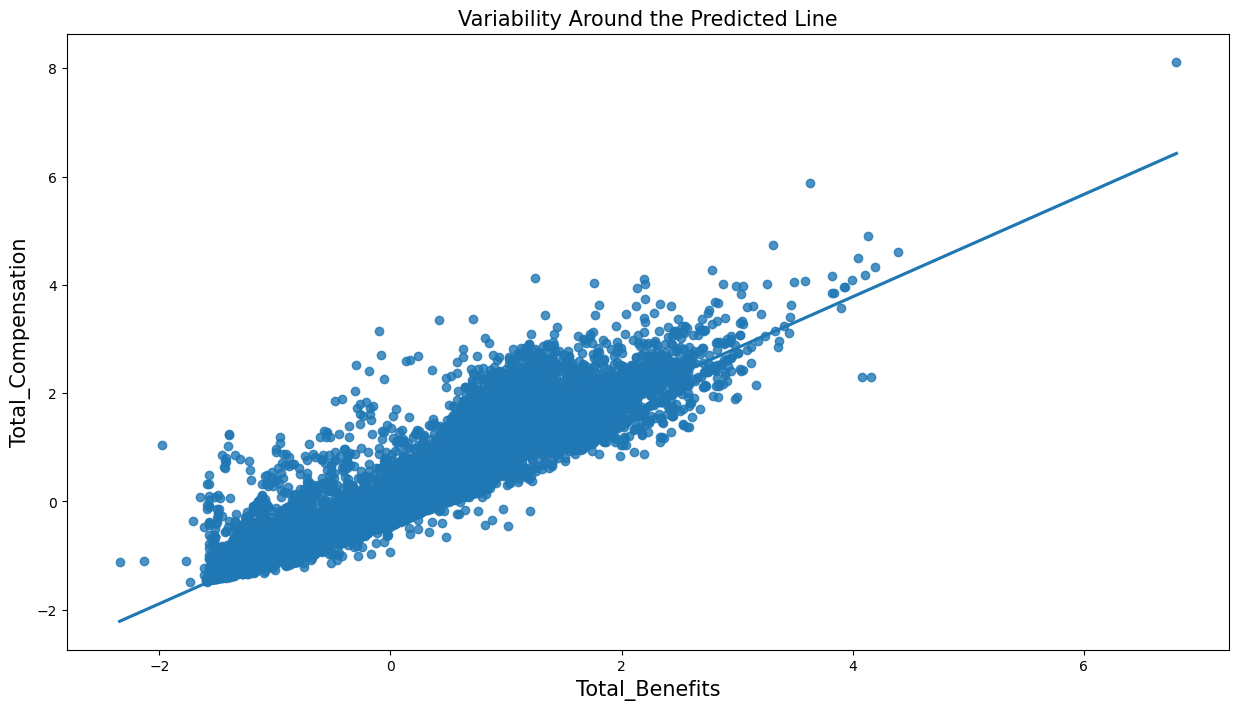

In [40]:
# set the plot size using figure()
# pass width and height in inches to 'figsize' 
plt.figure(figsize = (15,8))

# plot a regression plot
# independent variable on x-axis and dependent variable on y-axis
sns.regplot(x = X_train_slr['Total_Benefits'], y = y_train_slr)

# add axes and plot labels
# set text size using 'fontsize'
plt.title('Variability Around the Predicted Line', fontsize = 15)
plt.xlabel('Total_Benefits', fontsize = 15)
plt.ylabel('Total_Compensation', fontsize = 15)

# display the plot
plt.show()

<a id="inf"></a>
## 4.3 Inferences about Slope and Intercept

In [41]:
# print the model summary
print(SLR_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                 2.818e+05
Date:                Sat, 11 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:12:42   Log-Likelihood:                -11146.
No. Observations:               35000   AIC:                         2.230e+04
Df Residuals:                   34998   BIC:                         2.231e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          0.0012      0.002      0.

<a id="inter"></a>
### 4.3.1 Interpretation of Slope and Intercept

<a id="t_test"></a>
### 4.3.2 The t-test for Slope and Intercept

In [42]:
# perform t_test for intercept
# 'params[0]' returns the value of intercept 
# 'bse[0]' returns the standard error of intercept
t_intercept = SLR_model.params[0] / SLR_model.bse[0]

# print the value of t-statistic
t_intercept

np.float64(0.6544672819975199)

In [43]:
# t_test for slope
# 'params[1]' returns the value of slope
# 'bse[1]' returns the standard error of slope
t_slope = SLR_model.params[1] / SLR_model.bse[1]

# print the value of t-statistic
t_slope

np.float64(530.8282282066604)

In [44]:
# calculate p-value for intercept
# use 'sf' (Survival function) from t-distribution to calculate the corresponding p-value

# pass degrees of freedom and t-statistic value for intercept
# degrees of freedom = n - 1 = 1043 - 1 = 1042
pval = stats.t.sf(np.abs(t_intercept), 1042)*2 
pval

np.float64(0.5129552245384941)

In [45]:
# calculate p-value for slope
# use 'sf' (Survival function) from t-distribution to calculate the corresponding p-value

# pass degrees of freedom and t-statistic value for slope
# degrees of freedom = n - 1 = 1043 - 1 = 1042
pval = stats.t.sf(np.abs(t_slope), 1042)*2 
pval

np.float64(0.0)

<a id="ci"></a>
### 4.3.3 Confidence Interval for Slope and Intercept

In [46]:
# CI for intercept
# create a tuple using the above formula
# here, t_table_value = 1.9622
CI_inter_min, CI_inter_max = SLR_model.params[0] - (1.9622*SLR_model.bse[0]), SLR_model.params[0] + (1.9622*SLR_model.bse[0])

# print the confidence interval for intercept 
print('CI for intercept:', [CI_inter_min , CI_inter_max])

CI for intercept: [np.float64(-0.0023257820435197457), np.float64(0.004653701551209418)]


In [47]:
# CI for slope
# create a tuple using the above formula
# here, t_table_value = 1.9622
CI_slope_min, CI_slope_max = SLR_model.params[1] - (1.9622*SLR_model.bse[1]), SLR_model.params[1] + (1.9622*SLR_model.bse[1])

# print the confidence interval for slope
print('CI for slope:', [CI_slope_min,CI_slope_max])

CI for slope: [np.float64(0.9410453939546332), np.float64(0.9480283316875754)]


<a id="anova"></a>
### 4.3.4 ANOVA for SLR

In [48]:
# build a SLR model using 'ols' method
# pass the regression model to the parameter 'formula'
# concatenate the training dataset and pass to the parameter 'data' to build the model on training dataset
# 'axis=1' concats the data column-wise
# 'fit()' is used to fit the model
slr_ols = ols(formula = 'Total_Compensation ~ Total_Benefits', data = pd.concat([X_train_slr, y_train_slr], axis=1)).fit()
# this model returns the same result as of model built using 'OLS' 

In [49]:
# perform ANOVA on the above model using 'anova_lm'
# pass the linear model to 'anova_lm'
anova_slr = anova_lm(slr_ols)

# print the ANOVA results
anova_slr

,df,sum_sq,mean_sq,F,PR(>F)
Total_Benefits,1.000000,31194.286044,31194.286044,281778.607861,0.000000
Residual,34998.000000,3874.451759,0.110705,NaN,NaN


<a id="MLR"></a>
# 5. Multiple Linear Regression (MLR)

<a id="before"></a>
## 5.1 Assumptions Before MLR Model

In [50]:
# create dataframe of features by dropping the target variable
# 'axis = 1' drops the corresponding column(s)
df_feature = df_compensation.drop('Total_Compensation', axis = 1)

# create dataframe of target variable
df_target = df_compensation['Total_Compensation']

<a id="dep_num"></a>
### 5.1.1 Assumption on Dependent Variable

In [51]:
# check the data type of dependent variable
df_target.dtype

dtype('float64')

<a id="no_multi"></a>
### 5.1.2 No or Little Multicollinearity

<a id="corr"></a>
#### 5.1.2.1 Correlation Matrix

In [52]:
# set the plot size using figure()
# pass width and height in inches to 'figsize' 
plt.figure(figsize = (20,10))

# plot the heat map
# corr(): give the correlation matrix
# annot: prints the correlation values in the chart
# annot_kws: used to set the font size of the annotation
sns.heatmap(df_feature.corr(), annot = True, annot_kws = {"size": 11})

# rotation = 'horizontal' rotates the y-axis labels horizontally
# set text size using 'fontsize'
plt.yticks(rotation = 'horizontal', fontsize = 15)
plt.xticks(fontsize = 15)

# display the plot
plt.show()

ValueError: could not convert string to float: 'Fiscal'

<Figure size 2000x1000 with 0 Axes>

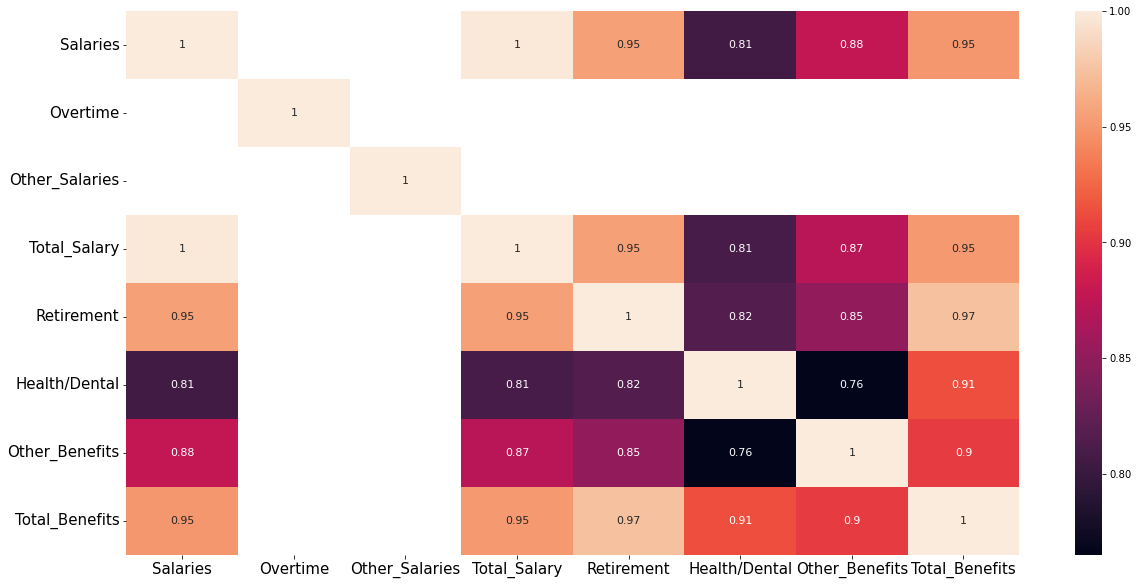

In [ ]:
# set the plot size using figure()
# pass width and height in inches to 'figsize' 
plt.figure(figsize = (20,10))

# plot the heat map
# corr(): give the correlation matrix
# annot: prints the correlation values in the chart
# annot_kws: sets the font size of the annotation
sns.heatmap(df_feature.corr()[np.abs(df_feature.corr()) > 0.6], annot = True, annot_kws = {"size": 11})

# rotate the y-axis labels
# set text size using 'fontsize'
plt.yticks(rotation = 'horizontal', fontsize = 15)
plt.xticks(fontsize = 15)

# display the plot
plt.show()

<a id="vif"></a>
#### 5.1.2.2 Variance Inflation Factor (VIF)

In [53]:
# filter the numerical features in the dataset
df_numeric_features_vif = df_feature.select_dtypes(include=[np.number])

# display the first five observations
df_numeric_features_vif.head()

,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits
0,0.648705,-0.369314,-0.456892,0.411547,0.791772,0.733102,0.779346,0.850618
1,-1.377859,-0.362024,-0.492148,-1.329386,-1.317033,-1.723007,-1.189746,-1.537720
2,0.297237,0.832423,0.938918,0.567518,0.581096,0.725779,0.886362,0.749777
3,-0.391742,-0.393450,-0.277886,-0.459563,-0.290025,-1.813040,-0.188591,-0.740029
4,-0.477156,-0.393450,-0.492148,-0.563880,-0.541001,-0.609580,-0.368541,-0.575981


#### Calculate the VIF for each numeric variable.

In [54]:
# create an empty dataframe to store the VIF for each variable
vif = pd.DataFrame()

# calculate VIF using list comprehension 
# use for loop to access each variable 
# calculate VIF for each variable and create a column 'VIF_Factor' to store the values 
vif["VIF_Factor"] = [variance_inflation_factor(df_numeric_features_vif.values, i) for i in range(df_numeric_features_vif.shape[1])]

# create a column of variable names
vif["Features"] = df_numeric_features_vif.columns

# sort the dataframe based on the values of VIF_Factor in descending order
# 'ascending = False' sorts the data in descending order
# 'reset_index' resets the index of the dataframe
# 'drop = True' drops the previous index
vif.sort_values('VIF_Factor', ascending = False).reset_index(drop = True)

,VIF_Factor,Features
0,inf,Salaries
1,inf,Overtime
2,inf,Other_Salaries
3,inf,Total_Salary
4,inf,Retirement
5,inf,Health/Dental
6,inf,Other_Benefits
7,inf,Total_Benefits


In [55]:
# for each numeric variable, calculate VIF and save it in a dataframe 'vif'

# use for loop to iterate the VIF function 
for ind in range(len(df_numeric_features_vif.columns)):
    
    # create an empty dataframe
    vif = pd.DataFrame()

    # calculate VIF using list comprehension
    # use for loop to access each variable 
    # calculate VIF for each variable and create a column 'VIF_Factor' to store the values 
    vif["VIF_Factor"] = [variance_inflation_factor(df_numeric_features_vif.values, i) for i in range(df_numeric_features_vif.shape[1])]

    # create a column of variable names
    vif["Features"] = df_numeric_features_vif.columns

    # filter the variables with VIF greater than 10 and store it in a dataframe 'multi' 
    # one can choose the threshold other than 10 (it depends on the business requirements)
    multi = vif[vif['VIF_Factor'] > 10]
    
    # if dataframe 'multi' is not empty, then sort the dataframe by VIF values
    # if dataframe 'multi' is empty (i.e. all VIF <= 10), then print the dataframe 'vif' and break the for loop using 'break' 
    # 'by' sorts the data using given variable(s)
    # 'ascending = False' sorts the data in descending order
    if(multi.empty == False):
        df_sorted = multi.sort_values(by = 'VIF_Factor', ascending = False)
    else:
        print(vif)
        break
    
    # use if-else to drop the variable with the highest VIF
    # if  dataframe 'df_sorted' is not empty, then drop the first entry in the column 'Features' from the numeric variables
    # select the variable using 'iloc[]'
    # 'axis=1' drops the corresponding column
    #  else print the final dataframe 'vif' with all values after removal of variables with VIF less than 10  
    if (df_sorted.empty == False):
        df_numeric_features_vif = df_numeric_features_vif.drop(df_sorted.Features.iloc[0], axis=1)
    else:
        print(vif)

   VIF_Factor        Features
0    1.510583        Overtime
1    1.656885  Other_Salaries
2    4.951942    Total_Salary
3    2.646291   Health/Dental
4    2.198707  Other_Benefits


In [56]:
# display the first 5 observations
df_numeric_features_vif.head()

,Overtime,Other_Salaries,Total_Salary,Health/Dental,Other_Benefits
0,-0.369314,-0.456892,0.411547,0.733102,0.779346
1,-0.362024,-0.492148,-1.329386,-1.723007,-1.189746
2,0.832423,0.938918,0.567518,0.725779,0.886362
3,-0.393450,-0.277886,-0.459563,-1.813040,-0.188591
4,-0.393450,-0.492148,-0.563880,-0.609580,-0.368541


<a id="model"></a>
## 5.2 Build the MLR Model

<a id="full"></a>
### 5.2.1 MLR Full Model

#### Filter numerical and categorical variables

In [58]:
# create dataframe of features by dropping the target variable
# 'axis = 1' drops the corresponding column(s)
df_feature = df_compensation.drop('Total_Compensation', axis = 1)

# create dataframe of target variable
df_target = df_compensation['Total_Compensation']

In [ ]:
# filter the numerical features in the dataset
# 'select_dtypes' is used to select the variables with given data type
# 'include=[np.number]' will include all the numerical variables
df_num = df_feature.select_dtypes(include=[np.number])

# display numerical features
df_num.columns

Index(['Salaries', 'Overtime', 'Other_Salaries', 'Total_Salary', 'Retirement',
       'Health/Dental', 'Other_Benefits', 'Total_Benefits'],
      dtype='object')

In [ ]:
# filter the categorical features in the dataset
# 'select_dtypes' is used to select the variables with given data type
# 'include=[np.object]' will include all the categorical variables
df_cat = df_feature.select_dtypes(include=[np.object])

# display categorical features
df_cat.columns

Index(['Year_Type', 'Year'], dtype='object')

In [ ]:
# use 'get_dummies' from pandas to create dummy variables
# use 'drop_first' to create (n-1) dummy variables
encoded_data = pd.get_dummies(data = df_cat, drop_first=True)

In [ ]:
encoded_data.head()

,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,1,0,1,0
1,0,0,1,0
3,1,1,0,0
4,1,0,0,0
5,0,0,0,0


In [ ]:
# concat the dummy variables with numeric features to create a dataframe of all independent variables
# 'axis=1' concats the dataframes along columns 
df_compensation_dummy = pd.concat([df_num, encoded_data], axis=1)

# display first five observations
df_compensation_dummy.head()

,Salaries,Overtime,Other_Salaries,Total_Salary,Retirement,Health/Dental,Other_Benefits,Total_Benefits,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,0.983488,-0.228091,-0.474919,0.926912,1.178494,0.916565,1.145315,1.160922,1,0,1,0
1,-1.252266,-0.167552,-0.587276,-1.263215,-1.180529,-1.491462,-1.259970,-1.365191,0,0,1,0
3,-0.164358,-0.428525,0.095551,-0.168961,-0.031662,-1.579733,-0.037039,-0.521484,1,1,0,0
4,-0.258589,-0.428525,-0.587276,-0.300194,-0.312417,-0.399832,-0.256852,-0.347973,1,0,0,0
5,0.536538,-0.428525,0.019113,0.511845,0.511937,0.994002,0.703228,0.731784,0,0,0,0


In [59]:
# set of independent variables
# create a copy of 'df_compensation_dummy' and store in the dataframe 'X_full'
X_full = df_compensation_dummy.copy()

# dependent variable
# create a copy of 'df_target' and store in the dataframe 'y_full'
y_full = df_target.copy()

# to estimate the regression coefficient, a constant term of '1' needs to be added as a separate column
# 'sm.add_constant' adds the intercept to the model
X_full = sm.add_constant(X_full)

# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code 
# 'test_size' returns the proportion of data to be included in the testing set
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, random_state=1, test_size = 0.3)

# checking the dimensions of the train & test subset
# print dimension of train set
print('X_train_full', X_train_full.shape)
print('y_train_full', y_train_full.shape)

# print dimension of test set
print('X_test_full', X_test_full.shape)
print('y_test_full', y_test_full.shape)

NameError: name 'df_compensation_dummy' is not defined

In [ ]:
# build a model on training dataset
# fit() is used to fit the OLS model
MLR_full_model = sm.OLS(y_train_full, X_train_full).fit()

# print the summary output
print(MLR_full_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.706e+08
Date:                Mon, 22 May 2023   Prob (F-statistic):               0.00
Time:                        12:30:37   Log-Likelihood:             1.2482e+05
No. Observations:               26404   AIC:                        -2.496e+05
Df Residuals:                   26393   BIC:                        -2.495e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.251e-14   6.52e-05  

In [ ]:
y_pred_full = MLR_full_model.predict(X_test_full)

<a id="signi_var"></a>
### 5.2.2 MLR Model after Removing Insignificant Variables

In [60]:
# display numeric features obtained from VIF
df_numeric_features_vif.columns

Index(['Overtime', 'Other_Salaries', 'Total_Salary', 'Health/Dental',
       'Other_Benefits'],
      dtype='object')

In [61]:
# filter the categorical features in the dataset
# 'select_dtypes' is used to select the variables with given data type
# 'include=[np.object]' will include all the categorical variables
df_cat = df_feature.select_dtypes(include=[np.object])

# display categorical features
df_cat.columns

AttributeError: module 'numpy' has no attribute 'object'.
`np.object` was a deprecated alias for the builtin `object`. To avoid this error in existing code, use `object` by itself. Doing this will not modify any behavior and is safe. 
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [ ]:
# use 'get_dummies' from pandas to create dummy variables
# use 'drop_first' to create (n-1) dummy variables
encoded_data = pd.get_dummies(data = df_cat, drop_first=True)

In [ ]:
# concat the dummy variables with numeric features to create a dataframe of all independent variables
# 'axis=1' concats the dataframes along columns 
df_compensation_dummy = pd.concat([df_numeric_features_vif, encoded_data], axis=1)

# display first five observations
df_compensation_dummy.head()

,Overtime,Other_Salaries,Retirement,Health/Dental,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,-0.228091,-0.474919,1.178494,0.916565,1,0,1,0
1,-0.167552,-0.587276,-1.180529,-1.491462,0,0,1,0
3,-0.428525,0.095551,-0.031662,-1.579733,1,1,0,0
4,-0.428525,-0.587276,-0.312417,-0.399832,1,0,0,0
5,-0.428525,0.019113,0.511937,0.994002,0,0,0,0


In [ ]:
# set of independent variables
# create a copy of 'df_compensation_dummy' and store in the dataframe 'X_signi_var'
X_signi_var = df_compensation_dummy.copy()

# dependent variable
# create a copy of 'df_target' and store in the dataframe 'y_signi_var'
y_signi_var = df_target.copy()

# to estimate the regression coefficient, a constant term of '1' needs to be added as a separate column
# 'sm.add_constant' adds the intercept to the model
X_signi_var = sm.add_constant(X_signi_var)

# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code 
# 'test_size' returns the proportion of data to be included in the testing set
X_train_signi_var, X_test_signi_var, y_train_signi_var, y_test_signi_var = train_test_split(X_signi_var, y_signi_var, 
                                                                                            random_state=1, test_size = 0.3)

# checking the dimensions of the train & test subset
# print dimension of train set
print('X_train_signi_var', X_train_signi_var.shape)
print('y_train_signi_var', y_train_signi_var.shape)

# print dimension of test set
print('X_test_signi_var', X_test_signi_var.shape)
print('y_test_signi_var', y_test_signi_var.shape)

X_train_signi_var (26404, 9)
y_train_signi_var (26404,)
X_test_signi_var (11317, 9)
y_test_signi_var (11317,)


In [ ]:
# build a model on training dataset
# fit() is used to fit the OLS model
MLR_model_vif = sm.OLS(y_train_signi_var, X_train_signi_var).fit()

# print the summary output
print(MLR_model_vif.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 6.605e+04
Date:                Mon, 22 May 2023   Prob (F-statistic):               0.00
Time:                        12:30:37   Log-Likelihood:                 2855.1
No. Observations:               26404   AIC:                            -5692.
Df Residuals:                   26395   BIC:                            -5619.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0537      0.003  

In [ ]:
# calculate p-values for all the independent variables in the MLR_model
# create a dataframe containing p-values 
# pass the column name to the parameter 'columns'
MLR_pvalues = pd.DataFrame(MLR_model_vif.pvalues, columns = ["P-Value"])

# print the dataframe
MLR_pvalues

,P-Value
const,0.000000
Overtime,0.000000
Other_Salaries,0.000000
Retirement,0.000000
Health/Dental,0.000000
Year_Type_Fiscal,0.020051
Year_2014,0.000000
Year_2015,0.000000
Year_2016,0.001959


In [ ]:
# subset the dataframe 'MLR_pvalues' such that the variables will have p-value greater than 0.05
# store the subset of a dataframe to a new dataframe 'insignificant_var' 
insignificant_var = MLR_pvalues[1:][MLR_pvalues[1:]['P-Value'] > 0.05]

# get the variable names with p-value greater than 0.05
insigni_var = insignificant_var.index

# convert the variables to the type 'list' using 'to_list()'
insigni_var = insigni_var.to_list()

# print the list of insignificant variables
insigni_var

[]

In [ ]:
# drop the insignificant variables from the dataframe 'X_train_signi_var'
# 'axis = 1' drops the corresponding column(s)
X_train_signi_var = X_train_signi_var.drop(insigni_var, axis=1)

# drop the insignificant variables from the dataframe 'X_test_signi_var'
# 'axis = 1' drops the corresponding column(s)
X_test_signi_var = X_test_signi_var.drop(insigni_var, axis=1)

# building a model on training dataset
# fit() is used to fit the OLS model
MLR_model_with_significant_var = sm.OLS(y_train_signi_var, X_train_signi_var).fit()

# print the summary output
print(MLR_model_with_significant_var.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 6.605e+04
Date:                Mon, 22 May 2023   Prob (F-statistic):               0.00
Time:                        12:30:37   Log-Likelihood:                 2855.1
No. Observations:               26404   AIC:                            -5692.
Df Residuals:                   26395   BIC:                            -5619.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0537      0.003  

In [ ]:
y_pred_signi_var = MLR_model_with_significant_var.predict(X_test_signi_var)

<a id="interaction"></a>
### 5.2.3 MLR Model with Interaction Effect

In [ ]:
df_interaction = df_compensation_dummy.copy()
df_interaction = df_interaction.drop(insigni_var, axis = 1)

# add the interaction variable in the original data
df_interaction['Other_Salaries*Retirement'] = df_interaction['Other_Salaries']*df_interaction['Retirement'] 

# print the data with interaction
df_interaction.head()

,Overtime,Other_Salaries,Retirement,Health/Dental,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016,Other_Salaries*Retirement
0,-0.228091,-0.474919,1.178494,0.916565,1,0,1,0,-0.559689
1,-0.167552,-0.587276,-1.180529,-1.491462,0,0,1,0,0.693297
3,-0.428525,0.095551,-0.031662,-1.579733,1,1,0,0,-0.003025
4,-0.428525,-0.587276,-0.312417,-0.399832,1,0,0,0,0.183475
5,-0.428525,0.019113,0.511937,0.994002,0,0,0,0,0.009785


In [ ]:
df_compensation_dummy.head()

,Overtime,Other_Salaries,Retirement,Health/Dental,Year_Type_Fiscal,Year_2014,Year_2015,Year_2016
0,-0.228091,-0.474919,1.178494,0.916565,1,0,1,0
1,-0.167552,-0.587276,-1.180529,-1.491462,0,0,1,0
3,-0.428525,0.095551,-0.031662,-1.579733,1,1,0,0
4,-0.428525,-0.587276,-0.312417,-0.399832,1,0,0,0
5,-0.428525,0.019113,0.511937,0.994002,0,0,0,0


In [ ]:
# set of independent variables
# create a copy of 'df_num' and store in the dataframe 'X_inter'
X_inter = df_interaction.copy()

# dependent variable
# create a copy of 'df_target' and store in the dataframe 'y_inter'
y_inter = df_target.copy()

# to estimate the regression coefficient, a constant term of '1' needs to be added as a separate column
# 'sm.add_constant' adds the intercept to the model
X_inter = sm.add_constant(X_inter)

# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code 
# 'test_size' returns the proportion of data to be included in the testing set
X_train_inter, X_test_inter, y_train_inter, y_test_inter = train_test_split(X_inter, y_inter, random_state=1, test_size = 0.3)

# checking the dimensions of the train & test subset
# print dimension of train set
print('X_train_inter', X_train_inter.shape)
print('y_train_inter', y_train_inter.shape)

# print dimension of test set
print('X_test_inter', X_test_inter.shape)
print('y_test_inter', y_test_inter.shape)

X_train_inter (26404, 10)
y_train_inter (26404,)
X_test_inter (11317, 10)
y_test_inter (11317,)


In [ ]:
# build a model on training dataset
# 'sm.add_constant' adds the intercept to the model
# fit() is used to fit the OLS model
MLR_model_with_interaction = sm.OLS(y_train_inter, X_train_inter).fit()

# print the summary output
print(MLR_model_with_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                 6.072e+04
Date:                Mon, 22 May 2023   Prob (F-statistic):               0.00
Time:                        12:30:37   Log-Likelihood:                 3278.2
No. Observations:               26404   AIC:                            -6536.
Df Residuals:                   26394   BIC:                            -6455.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
y_pred_inter = MLR_model_with_interaction.predict(X_test_inter)

<a id="assum"></a>
## 5.3 Assumptions After MLR Model

<a id="linear_reln"></a>
### 5.3.1 Linear Relationship between Dependent and Independent Variable

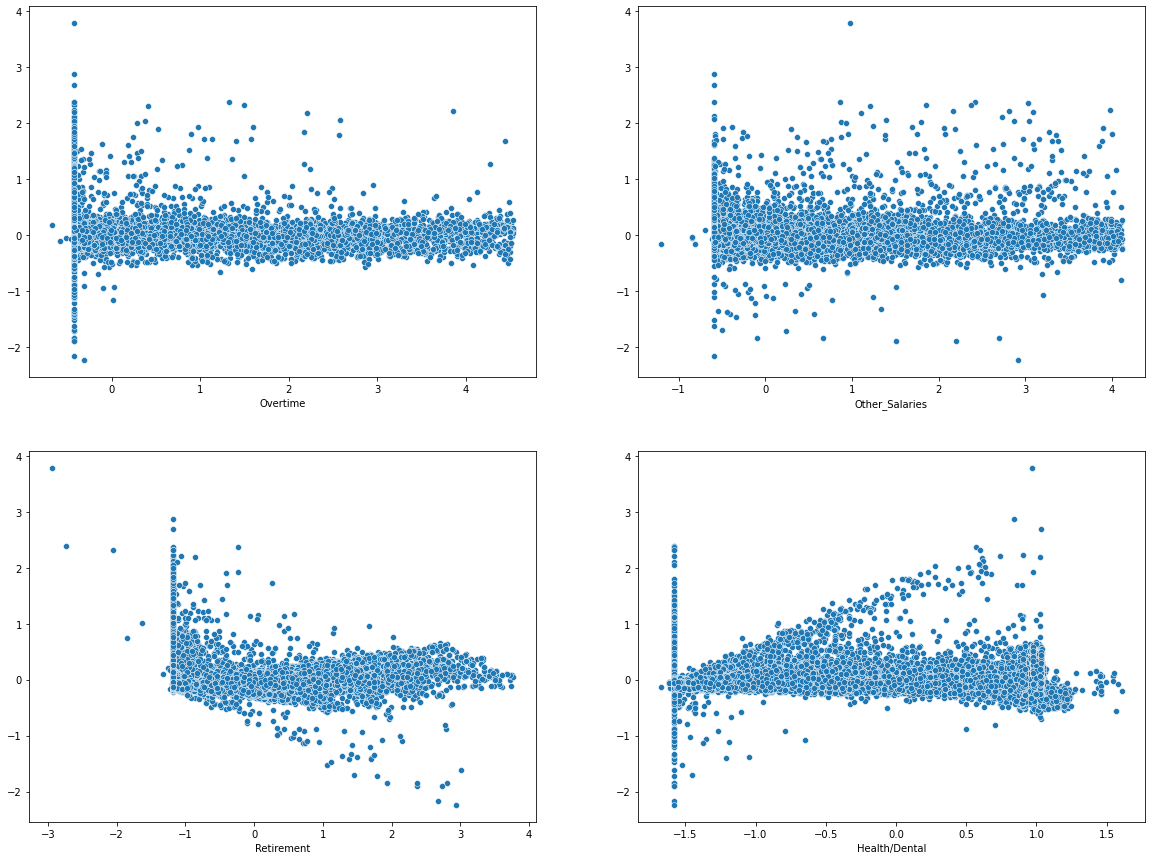

In [ ]:
# create subplots of scatter plots
# pass the number of rows in a subplot to 'nrows'
# pass the number of columns in a subplot to 'ncolumns'
# set plot size using 'figsize'
fig, ax = plt.subplots(nrows = 2, ncols= 2, figsize=(20, 15))

# use for loop to create scatter plot for residuals and each independent variable (do not consider the intercept)
# 'ax' assigns axes object to draw the plot onto 
for variable, subplot in zip(X_train_signi_var.columns[1:5], ax.flatten()):
    sns.scatterplot(X_train_signi_var[variable], MLR_model_with_significant_var.resid , ax=subplot)

# display the plot
plt.show()

<a id="auto"></a>
### 5.3.2 Autocorrelation

In [ ]:
# print the model summary
print(MLR_model_with_significant_var.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 6.605e+04
Date:                Mon, 22 May 2023   Prob (F-statistic):               0.00
Time:                        12:30:38   Log-Likelihood:                 2855.1
No. Observations:               26404   AIC:                            -5692.
Df Residuals:                   26395   BIC:                            -5619.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0537      0.003  

<a id="sked"></a>
### 5.3.3 Heteroskedasticity

In [ ]:
# create vector of result parmeters
name = ['f-value','p-value']

# perform Breusch-Pagan test using residuals and independent variables
# compute residuals using 'resid'
# 'exog' returns the independent variables in the model alng with the intercept
test = sms.het_breuschpagan(MLR_model_with_significant_var.resid, MLR_model_with_significant_var.model.exog)

# print the output
# use 'lzip' to zip the column names and test results
# use 'test[2:]' to retrieve the F-statistic and its corresponding p-value 
lzip(name, test[2:])

[('f-value', 77.78364079815607), ('p-value', 1.3149059750886006e-127)]

<a id="normality"></a>
### 5.3.4 Tests for Normality

<a id="qq"></a>
#### 1. Q-Q Plot

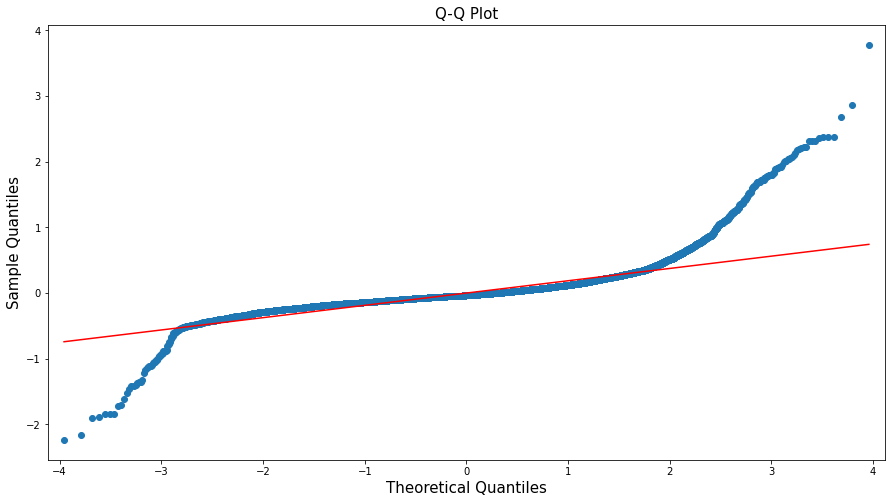

In [ ]:
# set the plot size using 'rcParams'
# once the plot size is set using 'rcParams', it sets the size of all the forthcoming plots in the file
# pass width and height in inches to 'figure.figsize' 
plt.rcParams['figure.figsize'] = [15,8]

# plot the Q-Q plot
# 'r' represents the regression line
qqplot(MLR_model_with_significant_var.resid, line = 'r')

# set plot and axes labels
# set text size using 'fontsize'
plt.title('Q-Q Plot', fontsize = 15)
plt.xlabel('Theoretical Quantiles', fontsize = 15)
plt.ylabel('Sample Quantiles', fontsize = 15)

# display the plot
plt.show()

<a id="SWT"></a>
#### 2. Shapiro Wilk Test

The Shapiro Wilk test is used to check the normality of the residuals. The test hypothesis is given as:<br>

<p style='text-indent:25em'> <strong> H<sub>o</sub>:  Residuals are normally distributed </strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>:  Residuals are not normally distributed </strong> </p>

In [ ]:
# perform Shapiro Wilk test using 'shapiro()' from scipy library
# shapiro() returns a tuple having the values of test statistics and the corresponding p-value
# 'resid' returns the residuals in the model
# pass the residuals to 'shapiro()'
stat, p_value = shapiro(MLR_model_with_significant_var.resid)

# print the test statistic and corresponding p-value 
print('Test statistic:', stat)
print('P-Value:', p_value)

Test statistic: 0.7444038391113281
P-Value: 0.0


<a id="eval"></a>
# 6. Model Evaluation

In [ ]:
# print the model summary
print(MLR_model_with_significant_var.summary())

                            OLS Regression Results                            
Dep. Variable:     Total_Compensation   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                 6.605e+04
Date:                Mon, 22 May 2023   Prob (F-statistic):               0.00
Time:                        12:30:38   Log-Likelihood:                 2855.1
No. Observations:               26404   AIC:                            -5692.
Df Residuals:                   26395   BIC:                            -5619.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0537      0.003  

<a id="R_squared"></a>
## 6.1 R-Squared

In [ ]:
# calculate R-Squared on train dataset
# use 'rsquared' from statsmodel
r_sq_mlr = MLR_model_with_significant_var.rsquared

# print the value
r_sq_mlr

0.952426668116827

<a id="Adj_R_test"></a>
## 6.2 Adjusted R-Squared

In [ ]:
# calculate adjusted R-Squared on train dataset
# use 'rsquared_adj' from statsmodel
adj_r_sq = MLR_model_with_significant_var.rsquared_adj

# print the value
adj_r_sq

0.9524122492247995

In [ ]:
# calculate adjusted R-Squared on train dataset using the formula
# 'n' denotes total number of observations
n = len(X_train_signi_var)

# 'k' denotes number of predictors (including the intercept)
k = len(X_train_signi_var.columns)

# calculate adjusted R-squared
# 'r_sq_mlr' represents the R-Squared value
adj_r_sq = 1 - (((1 - r_sq_mlr) * (n - 1)) / (n - k - 1))

# print the value
adj_r_sq

0.952410446248715

<a id="overall"></a>
## 6.3 Overall F-Test & p-value of the Model

In [ ]:
# compute f_value using the below formula 
# f_value = (r_sq / k-1)/((1- r_sq)/n-k)

# k = number of beta coefficients
k = len(X_train_signi_var.columns)

# n = number of observations
n = len(X_train_signi_var)

# calculate value of F-statistic
# 'r_sq_mlr' represents the R-Squared value
f_value = (r_sq_mlr / (k - 1))/((1-r_sq_mlr)/(n - k))

# print the value
f_value

66054.08143021923

In [ ]:
# calculate p-value for F-statistic
# use 'sf' (Survival function) from f-distribution to calculate the corresponding p-value

# degrees of freedom 
# dfn = k-1 = 6-1 = 5
# dfd = n-k = 1043-5 = 1038
p_val = stats.f.sf(f_value, dfn = 5, dfd = 1038)

# print the value
p_val

0.0

<a id="ml_perf"></a>
# 7. Model Performance

In [ ]:
# For training set:
# train_pred: prediction made by the model on the training dataset 'X_train_signi_var'
# y_train_signi_var: actual values of the target variable for the train dataset

# For testing set:
# test_pred: prediction made by the model on the test dataset 'X_test_signi_var'
# y_test_signi_var: actual values of the target variable for the test dataset

# predict the output of the target variable from the train data 
# train_pred can also be obtained from "MLR_model_with_significant_var.fittedvalues"
train_pred = MLR_model_with_significant_var.predict(X_train_signi_var)

# predict the output of the target variable from the test data
test_pred = MLR_model_with_significant_var.predict(X_test_signi_var)

<a id="mse"></a>
## 7.1 Mean Squared Error (MSE)

In [ ]:
# calculate the MSE using the "mean_squared_error" function

# calculate the MSE for the train data
# round the value upto 4 digits using 'round()'
mse_train = round(mean_squared_error(y_train_signi_var, train_pred),4)

# print the MSE for the training set
print("Mean Squared Error (MSE) on training set: ", mse_train)

# calculate the MSE for the test data
# round the value upto 4 digits using 'round()'
mse_test = round(mean_squared_error(y_test_signi_var, test_pred),4)

# print the MSE for the test set
print("Mean Squared Error (MSE) on test set: ", mse_test)

Mean Squared Error (MSE) on training set:  0.0472
Mean Squared Error (MSE) on test set:  0.042


<a id="rmse"></a>
## 7.2 Root Mean Squared Error (RMSE)

In [ ]:
# calculate the MSE using the "mean_squared_error" function

# MSE for the train data
mse_train = mean_squared_error(y_train_signi_var, train_pred)

# take the square root of the MSE to calculate the RMSE
# round the value upto 4 digits using 'round()'
rmse_train = round(np.sqrt(mse_train), 4)

# print the RMSE for the train set
print("Root Mean Squared Error (RMSE) on training set: ", rmse_train)

# MSE for the test data
mse_test = mean_squared_error(y_test_signi_var, test_pred)

# take the square root of the MSE to calculate the RMSE
# round the value upto 4 digits using 'round()'
rmse_test = round(np.sqrt(mse_test), 4)

# print the RMSE for the test set
print("Root Mean Squared Error (RMSE) on test set: ", rmse_test)

Root Mean Squared Error (RMSE) on training set:  0.2172
Root Mean Squared Error (RMSE) on test set:  0.2049


<a id="mae"></a>
## 7.3 Mean Absolute Error (MAE)

In [ ]:
# calculate the MAE using the "mean_absolute_error" function

# calculate the MAE for the train data
# round the value upto 4 digits using 'round()'
mae_train = round(mean_absolute_error(y_train_signi_var, train_pred),4)

# print the MAE for the training set
print("Mean Absolute Error (MAE) on training set: ", mae_train)

# calculate the MAE for the test data
# round the value upto 4 digits using 'round()'
mae_test = round(mean_absolute_error(y_test_signi_var, test_pred),4)

# print the MAE for the test set
print("Mean Absolute Error (MAE) on test set: ", mae_test)

Mean Absolute Error (MAE) on training set:  0.1297
Mean Absolute Error (MAE) on test set:  0.1272


<a id="mape"></a>
## 7.4 Mean Absolute Percentage Error (MAPE)

In [ ]:
# define a function to calculate MAPE
# pass the actual and predicted values as input to the function
# return the calculated MAPE 
def mape(actual, predicted):
    return (np.mean(np.abs((actual - predicted) / actual)) * 100)

In [ ]:
# calculate the mape using the "mape()" function created above

# calculate the MAPE for the train data
# round the value upto 4 digits using 'round()'
mape_train = round(mape(y_train_signi_var, train_pred),4)

# print the MAPE for the training set
print("Mean Absolute Percentage Error (MAPE) on training set: ", mape_train)

# calculate the MAPE for the test data
# round the value upto 4 digits using 'round()'
mape_test = round(mape(y_test_signi_var, test_pred),4)

# print the MAPE for the test set
print("Mean Absolute Percentage Error (MAPE) on test set: ", mape_test)

Mean Absolute Percentage Error (MAPE) on training set:  76.6985
Mean Absolute Percentage Error (MAPE) on test set:  72.0685


<a id="compare"></a>
# 8. Compare Model Performances

Let us compare the model performance metrics (MSE, RMSE, MAE, MAPE) for `MLR_full_model`, `MLR_model_with_significant_var` and `MLR_interaction_model` to find the best model.

In [ ]:
# create the table for all the model performance metrics
# metrics considered for model comparision are MSE, RMSE, MAE and MAPE
# create a list of column names
cols = ['Model_Name', 'R-squared', 'Adj. R-squared', 'MSE', 'RMSE', 'MAE', 'MAPE']

# creating a empty dataframe of the colums
result_table = pd.DataFrame(columns = cols)

In [ ]:
# calculate R-squared, Adjusted R-squared, MSE, RMSE, MAE and MAPE for full model
# use 'rsquared' to calculate R-squared value
# use 'rsquared_adj' to calculate Adjusted R-squared value
# use 'mean_squared_error' to calculate MSE
# use 'rmse' to calculate RMSE
# use 'mean_absolute_error' to calculate MAE
# use the defined function 'mape' to calculate MAPE
MLR_full_model_metrics = pd.Series({'Model_Name': "MLR Full Model",
                     'R-squared': MLR_full_model.rsquared,
                     'Adj. R-squared': MLR_full_model.rsquared_adj,
                     'MSE': mean_squared_error(y_test_full, y_pred_full),
                     'RMSE': rmse(y_test_full, y_pred_full),
                     'MAE': mean_absolute_error(y_test_full, y_pred_full),
                     'MAPE': mape(y_test_full, y_pred_full)
                   })

# append the values to the result table
result_table = result_table.append(MLR_full_model_metrics, ignore_index = True)

# print the result table
result_table

,Model_Name,R-squared,Adj. R-squared,MSE,RMSE,MAE,MAPE
0,MLR Full Model,0.999995,0.999995,0.000005,0.002173,0.001806,0.245462


Now, calculate performance measure for `MLR_model_with_significant_var`

In [ ]:
# calculate R-squared, Adjusted R-squared, MSE, RMSE, MAE and MAPE for model with significant variables
# use 'rsquared' to calculate R-squared value
# use 'rsquared_adj' to calculate Adjusted R-squared value
# use 'mean_squared_error' to calculate MSE
# use 'rmse' to calculate RMSE
# use 'mean_absolute_error' to calculate MAE
# use the defined function 'mape' to calculate MAPE
MLR_model_signi_var_metrics = pd.Series({'Model_Name': "MLR Model with Significant Variables",
                     'R-squared': MLR_model_with_significant_var.rsquared,
                     'Adj. R-squared': MLR_model_with_significant_var.rsquared_adj,
                     'MSE': mean_squared_error(y_test_signi_var, y_pred_signi_var),
                     'RMSE': rmse(y_test_signi_var, y_pred_signi_var),
                     'MAE': mean_absolute_error(y_test_signi_var, y_pred_signi_var),
                     'MAPE': mape(y_test_signi_var, y_pred_signi_var)
                   })

# append the values to the result table
result_table = result_table.append(MLR_model_signi_var_metrics, ignore_index = True)

# print the result table
result_table

,Model_Name,R-squared,Adj. R-squared,MSE,RMSE,MAE,MAPE
0,MLR Full Model,0.999995,0.999995,0.000005,0.002173,0.001806,0.245462
1,MLR Model with Significant Variables,0.952427,0.952412,0.041964,0.204850,0.127205,72.068481


Now, calculate the performance measures for `MLR_model_with_interaction`

In [ ]:
# calculate R-squared, Adjusted R-squared, MSE, RMSE, MAE and MAPE for model with interaction
# use 'rsquared' to calculate R-squared value
# use 'rsquared_adj' to calculate Adjusted R-squared value
# use 'mean_squared_error' to calculate MSE
# use 'rmse' to calculate RMSE
# use 'mean_absolute_error' to calculate MAE
# use the defined function 'mape' to calculate MAPE
MLR_model_interaction_metrics = pd.Series({'Model_Name': "MLR Model with Interaction",
                     'R-squared': MLR_model_with_interaction.rsquared,
                     'Adj. R-squared': MLR_model_with_interaction.rsquared_adj,
                     'MSE': mean_squared_error(y_test_inter, y_pred_inter),
                     'RMSE': rmse(y_test_inter, y_pred_inter),
                     'MAE': mean_absolute_error(y_test_inter, y_pred_inter),
                     'MAPE': mape(y_test_inter, y_pred_inter)
                   })

# append the values to the result table
result_table = result_table.append(MLR_model_interaction_metrics, ignore_index = True)

# print the result table
result_table

,Model_Name,R-squared,Adj. R-squared,MSE,RMSE,MAE,MAPE
0,MLR Full Model,0.999995,0.999995,0.000005,0.002173,0.001806,0.245462
1,MLR Model with Significant Variables,0.952427,0.952412,0.041964,0.204850,0.127205,72.068481
2,MLR Model with Interaction,0.953927,0.953911,0.041234,0.203062,0.126951,71.116137
